In [1]:

# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
#loading the dataset
FILENAME="../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df = pd.read_csv(FILENAME)  



In [3]:
#show the initial rows of the dataset
df.head() 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
#show the dataset shape
print(df.shape)

(225745, 79)


In [5]:
#show the names of the columns
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [6]:
#remove the spaces from the column names
df.columns = df.columns.str.strip()

In [7]:
# what attack types exist in the dataset?
print(df['Label'].value_counts())   

Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [8]:
# missing values in the dataset
print(df.isnull().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [9]:
# check if there are infinite values in the dataset
print(df.isin([np.inf, -np.inf]).sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


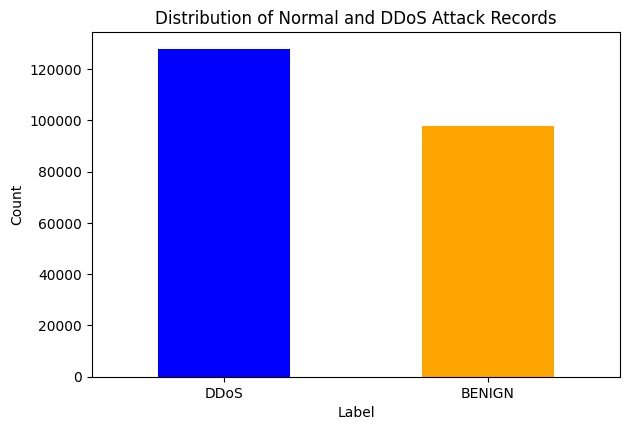

In [10]:
df['Label'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Distribution of Normal and DDoS Attack Records')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig('label_distribution.png')
plt.xticks(rotation=0)
plt.show()

In [11]:
# drop Identifier columns as they are not useful for modeling

cols_to_drop = ['Destination Port', 'Fwd Header Length.1']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Dataset shape after dropping identifier columns: {df.shape}")


Dataset shape after dropping identifier columns: (225745, 77)


In [12]:
# Replace infinite values with NaN, then drop those rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (225711, 77)


In [13]:
# Convert labels to binary: 1 = Attack, 0 = Normal
df['Label'] = df['Label'].map({'BENIGN': 0, 'DDoS': 1})

print(df['Label'].value_counts())
print("Label encoding complete: BENIGN=0, DDoS=1")

Label
1    128025
0     97686
Name: count, dtype: int64
Label encoding complete: BENIGN=0, DDoS=1


In [14]:

# Separate features (X) and labels (y)
X = df.drop(columns=['Label'])
y = df['Label']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (180568, 76)
Testing set:  (45143, 76)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


In [16]:


# Save the scaler for later use in the detection engine
joblib.dump(scaler, '../models/scaler.pkl')

# Save cleaned dataframe for reference
df.to_csv('../data/cleaned_data.csv', index=False)

print("Scaler and cleaned data saved.")

Scaler and cleaned data saved.


In [17]:
import joblib

scaler = joblib.load('../models/scaler.pkl')
print(scaler.feature_names_in_.tolist())

['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 